<a href="https://colab.research.google.com/github/DeemonDuck/IPO-Signal-Engine/blob/main/Model_1_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install xgboost

In [ ]:
pip install lightgbm

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("../data/processed/ipo_feature_engineered.csv")

df.head()

,Issue_Size(crores),QIB,HNI,RII,Offer Price,Month,Year,Demand_Gap,log_issue_size,Apply_Label,Nifty_Return_7d
0,650.00,36.72,38.24,32.55,385,8,2025,4.17,6.476972,0,-0.432323
1,792.00,163.90,57.71,20.28,150,8,2025,143.62,6.674561,1,-0.432323
2,4011.60,103.97,34.98,7.73,800,8,2025,96.24,8.296945,0,-0.432323
3,1300.00,133.21,72.00,50.87,675,8,2025,82.34,7.170120,1,-0.754718
4,254.26,1.30,1.84,2.22,158,8,2025,-0.92,5.538357,0,-0.754718


## Define Features and Target

In [ ]:
X = df.drop("Apply_Label", axis=1)
y = df["Apply_Label"]

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create Model Pipelines

### Logistic Regression Pipeline

In [ ]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])

###Random Forest Pipeline

In [ ]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

### Gradient Boosting Pipeline

In [ ]:
gb_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ))
])

### XG Boost

In [ ]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
])

### LightGBM

In [ ]:
import os
os.environ["LIGHTGBM_VERBOSE"] = "-1"

In [ ]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1,
        force_col_wise=True
    ))
])

### CatBoost

In [ ]:
from catboost import CatBoostClassifier

cat_pipeline = Pipeline([
    ("model", CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        verbose=0
    ))
])

### SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        kernel="rbf",
        random_state=42
    ))
])

## Final Model Dictionary

In [ ]:
models = {
    "Logistic Regression": log_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline,
    "CatBoost": cat_pipeline,
    "SVM": svm_pipeline
}

##Final Training + Evaluation Code

In [ ]:
import warnings
warnings.filterwarnings("ignore")

Training: Logistic Regression
Cross Val ROC AUC: 0.8803256410256409
Test ROC AUC: 0.9219306770327178
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        63
           1       0.84      0.84      0.84        49

    accuracy                           0.86       112
   macro avg       0.85      0.85      0.85       112
weighted avg       0.86      0.86      0.86       112



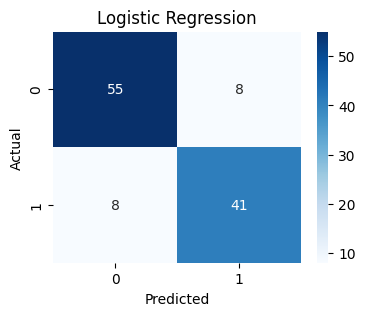

--------------------------------------------------
Training: Random Forest
Cross Val ROC AUC: 0.9064371794871795
Test ROC AUC: 0.9185293164885002
              precision    recall  f1-score   support

           0       0.87      0.86      0.86        63
           1       0.82      0.84      0.83        49

    accuracy                           0.85       112
   macro avg       0.85      0.85      0.85       112
weighted avg       0.85      0.85      0.85       112



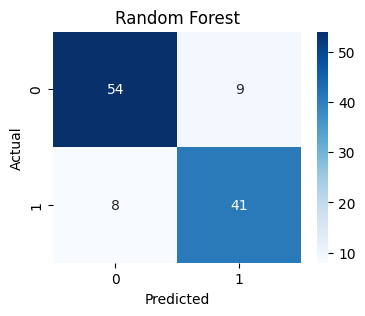

--------------------------------------------------
Training: Gradient Boosting
Cross Val ROC AUC: 0.8823358974358975
Test ROC AUC: 0.9041140265630061
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        63
           1       0.79      0.84      0.81        49

    accuracy                           0.83       112
   macro avg       0.83      0.83      0.83       112
weighted avg       0.83      0.83      0.83       112



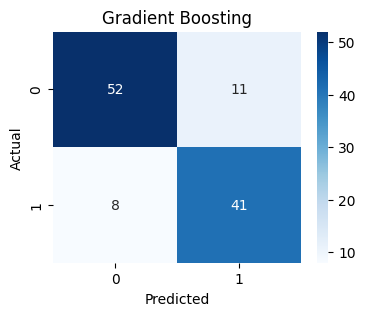

--------------------------------------------------
Training: XGBoost
Cross Val ROC AUC: 0.9064666666666665
Test ROC AUC: 0.9235503725299643
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        63
           1       0.82      0.82      0.82        49

    accuracy                           0.84       112
   macro avg       0.84      0.84      0.84       112
weighted avg       0.84      0.84      0.84       112



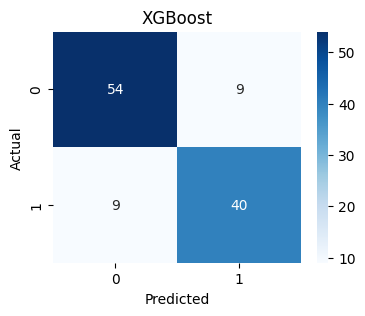

--------------------------------------------------
Training: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 357, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.439776 -> initscore=-0.242072
[LightGBM] [Info] Start training from score -0.242072
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

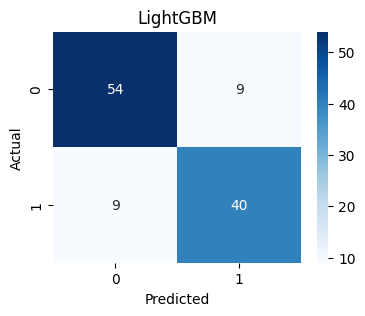

--------------------------------------------------
Training: CatBoost
Cross Val ROC AUC: 0.9080846153846153
Test ROC AUC: 0.9267897635244574
              precision    recall  f1-score   support

           0       0.88      0.83      0.85        63
           1       0.79      0.86      0.82        49

    accuracy                           0.84       112
   macro avg       0.84      0.84      0.84       112
weighted avg       0.84      0.84      0.84       112



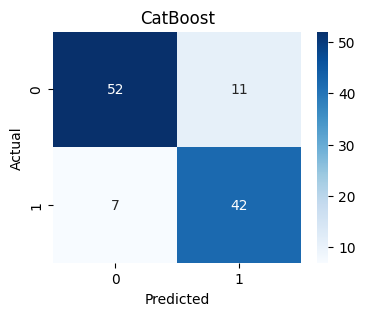

--------------------------------------------------
Training: SVM
Cross Val ROC AUC: 0.8771410256410258
Test ROC AUC: 0.9007126660187885
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        63
           1       0.87      0.82      0.84        49

    accuracy                           0.87       112
   macro avg       0.87      0.86      0.86       112
weighted avg       0.87      0.87      0.87       112



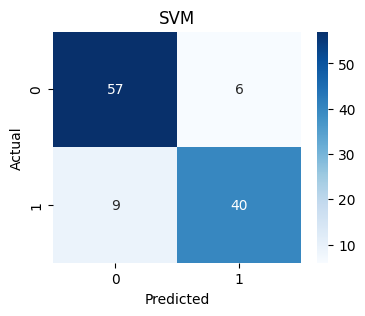

--------------------------------------------------


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

results = []

for name, model in models.items():

    print("Training:", name)

    # Cross Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")

    # Train model
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    # Metrics
    roc = roc_auc_score(y_test, probs)

    print("Cross Val ROC AUC:", cv_scores.mean())
    print("Test ROC AUC:", roc)

    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    results.append({
        "Model": name,
        "CV_ROC_AUC": cv_scores.mean(),
        "Test_ROC_AUC": roc
    })

    print("-"*50)

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("Test_ROC_AUC", ascending=False)

results_df.reset_index(drop=True)

,Model,CV_ROC_AUC,Test_ROC_AUC
0,CatBoost,0.908085,0.926790
1,XGBoost,0.906467,0.923550
2,Logistic Regression,0.880326,0.921931
3,LightGBM,0.899349,0.919663
4,Random Forest,0.906437,0.918529
5,Gradient Boosting,0.882336,0.904114
6,SVM,0.877141,0.900713
